# Baseline Models

This notebook evaluates transparent multi-step forecasting baselines for UCI electricity meter `MT_252`. The experiment predicts two complete future trajectories from each forecast origin: 4 steps for the next hour and 96 steps for the next 24 hours.

Models are compared on the final chronological test partition using leakage-safe supervised windows:

- Naive: repeats the current load across the horizon.
- Seasonal naive: replays the matching previous-day future steps.
- Direct multi-output Ridge: fits one linear model that predicts the full trajectory at once.

Ridge alpha is selected from `[0.1, 1.0, 10.0, 100.0]` using validation MAE only. The selected model is then evaluated once on the test partition without refitting on validation data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.baselines import naive_forecast, seasonal_naive_forecast, select_ridge_alpha
from src.config import RAW_DATA_DIR, RAW_DATA_FILENAME, FIGURES_DIR, TABLES_DIR
from src.data_loader import load_electricity_load_data
from src.evaluate import evaluate_multistep, per_step_metrics
from src.features import build_baseline_features
from src.forecasting import make_multistep_targets, split_supervised_by_time

sns.set_theme(style="whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## Load Data

The raw UCI file is loaded from `data/raw/LD2011_2014.txt`. Only meter `MT_252` is used for this baseline experiment.

In [2]:
raw_path = RAW_DATA_DIR / RAW_DATA_FILENAME
if not raw_path.exists():
    raise FileNotFoundError(f"Dataset not found: {raw_path}")

raw_df = load_electricity_load_data(raw_path)
series = raw_df["MT_252"].rename("load")
features = build_baseline_features(series)

print(f"series rows: {series.shape[0]:,}")
print(f"feature rows: {features.shape[0]:,}")
print(f"time span: {series.index.min()} to {series.index.max()}")
features.head()

series rows: 140,256
feature rows: 139,584
time span: 2011-01-01 00:15:00 to 2015-01-01 00:00:00


,current_load,load_lag_1,load_lag_4,load_lag_96,load_lag_192,load_lag_672,load_rolling_mean_4,load_rolling_std_4,load_rolling_mean_96,load_rolling_std_96,load_rolling_mean_672,load_rolling_std_672,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,is_weekend,is_holiday
timestamp,,,,,,,,,,,,,,,,,,,,
2011-01-08 00:15:00,136.978528,138.512270,156.932515,129.309816,138.512270,130.843558,143.117331,9.544597,279.325313,102.168881,259.261453,103.632199,0.065403,0.997859,-0.976966,-0.213396,0.0,1.0,1,0
2011-01-08 00:30:00,127.776074,136.978528,141.579755,120.092025,130.843558,115.490798,138.128834,2.619364,279.405196,102.053287,259.270582,103.621139,0.130526,0.991445,-0.978918,-0.204252,0.0,1.0,1,0
2011-01-08 00:45:00,135.444785,127.776074,135.444785,126.242331,132.377301,113.957055,134.677914,4.768599,279.485238,101.929959,259.288864,103.596815,0.195090,0.980785,-0.980785,-0.195090,0.0,1.0,1,0
2011-01-08 01:00:00,135.444785,135.444785,138.512270,135.444785,146.196319,121.641104,134.677914,4.768599,279.581097,101.788555,259.320840,103.555198,0.258819,0.965926,-0.982566,-0.185912,0.0,1.0,1,0
2011-01-08 01:15:00,130.843558,135.444785,136.978528,124.708589,130.843558,123.174847,133.911043,4.153394,279.581097,101.788555,259.341381,103.529213,0.321439,0.946930,-0.984262,-0.176717,0.0,1.0,1,0


## Run Baselines

For each horizon, targets and features are aligned by forecast origin, then split chronologically so no target vector crosses a train, validation, or test boundary.

In [3]:
HORIZONS = {"1h": 4, "24h": 96}
ALPHAS = (0.1, 1.0, 10.0, 100.0)

metric_rows = []
step_frames = []
alpha_frames = []
artifacts = {}

for horizon_label, horizon in HORIZONS.items():
    targets = make_multistep_targets(series, horizon).dropna()
    common_index = features.index.intersection(targets.index)
    X = features.loc[common_index]
    y = targets.loc[common_index]
    splits = split_supervised_by_time(X, y, series.index, horizon)
    X_train, y_train = splits["train"]
    X_val, y_val = splits["validation"]
    X_test, y_test = splits["test"]

    ridge_model, alpha_results = select_ridge_alpha(
        X_train, y_train, X_val, y_val, alphas=ALPHAS
    )
    selected_alpha = ridge_model.named_steps["ridge"].alpha
    alpha_results.insert(0, "horizon", horizon_label)
    alpha_results["selected"] = alpha_results["alpha"].eq(selected_alpha)
    alpha_frames.append(alpha_results)

    predictions = {
        "Naive": naive_forecast(X_test["current_load"], horizon),
        "Seasonal Naive": seasonal_naive_forecast(series, X_test.index, horizon),
        "Ridge": ridge_model.predict(X_test),
    }

    for model_name, prediction in predictions.items():
        metrics = evaluate_multistep(y_test, prediction)
        metric_rows.append(
            {
                "horizon": horizon_label,
                "horizon_steps": horizon,
                "model": model_name,
                "selected_alpha": selected_alpha if model_name == "Ridge" else np.nan,
                **metrics,
            }
        )
        step_metrics = per_step_metrics(y_test, prediction)
        step_metrics.insert(0, "model", model_name)
        step_metrics.insert(0, "horizon", horizon_label)
        step_frames.append(step_metrics)

    artifacts[horizon_label] = {
        "X_test": X_test,
        "y_test": y_test,
        "predictions": predictions,
    }

metrics_df = pd.DataFrame(metric_rows)
step_metrics_df = pd.concat(step_frames, ignore_index=True)
alpha_selection_df = pd.concat(alpha_frames, ignore_index=True)

metrics_df.to_csv(TABLES_DIR / "baseline_metrics.csv", index=False)
step_metrics_df.to_csv(TABLES_DIR / "baseline_metrics_by_step.csv", index=False)
alpha_selection_df.to_csv(TABLES_DIR / "ridge_alpha_selection.csv", index=False)

metrics_df

,horizon,horizon_steps,model,selected_alpha,MAE,RMSE,MAPE,Endpoint_MAE
0,1h,4,Naive,NaN,16.970033,27.091910,10.377395,21.557127
1,1h,4,Seasonal Naive,NaN,15.395150,24.912657,9.443368,15.394528
2,1h,4,Ridge,0.1,16.241292,22.759766,10.033431,20.180177
3,24h,96,Naive,NaN,75.092625,96.866962,44.866767,15.417331
4,24h,96,Seasonal Naive,NaN,15.326554,24.723413,9.399252,15.417331
5,24h,96,Ridge,0.1,24.380781,31.952616,14.574504,14.383238


## Forecast Examples

The examples below use the same relative test position for both horizons, making the short and long trajectories easy to compare.

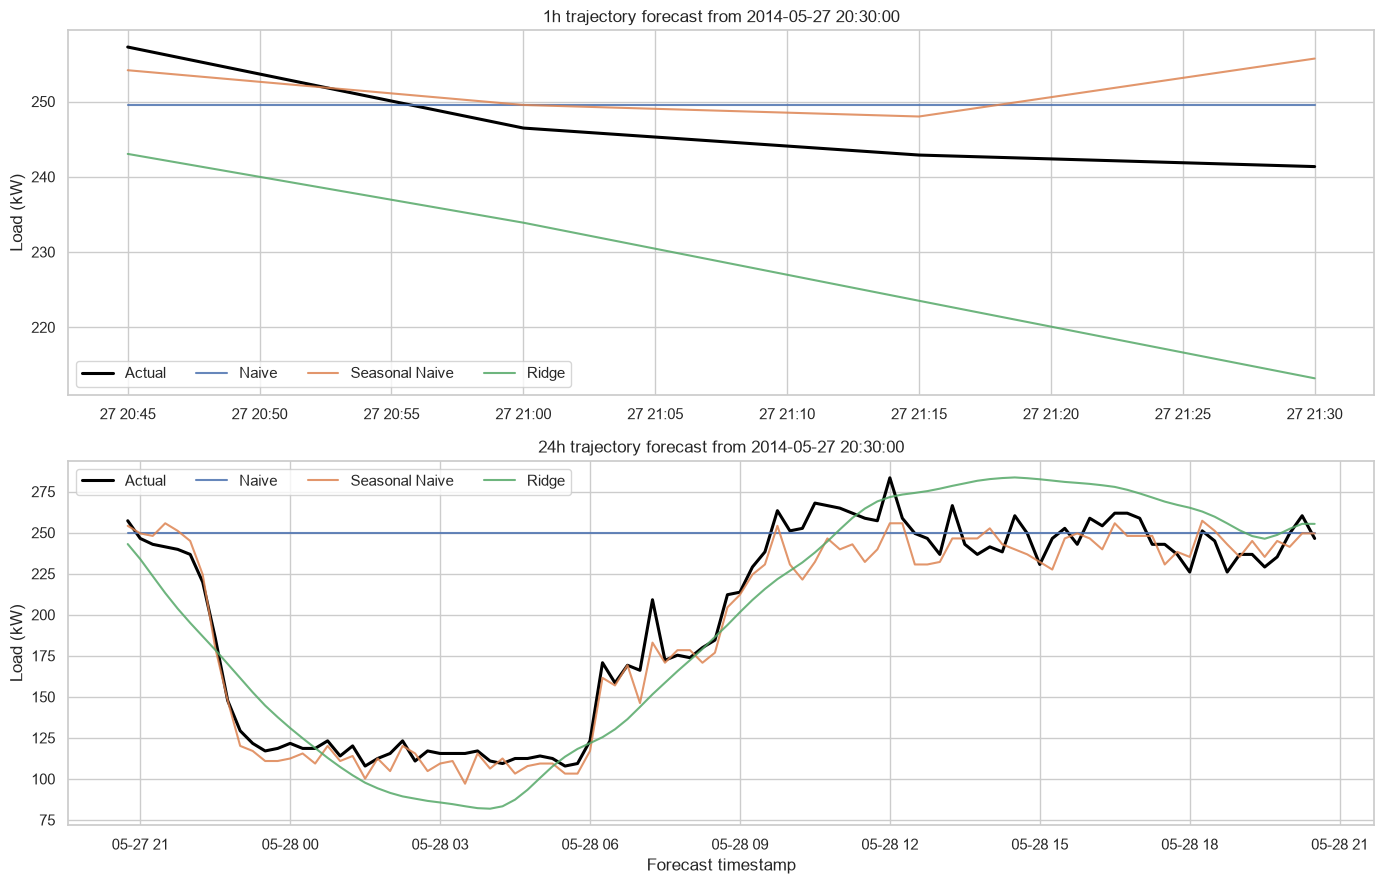

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
for ax, (horizon_label, horizon) in zip(axes, HORIZONS.items()):
    artifact = artifacts[horizon_label]
    example_position = min(96, len(artifact["y_test"]) - 1)
    origin = artifact["y_test"].index[example_position]
    future_index = pd.date_range(
        origin + pd.Timedelta(minutes=15), periods=horizon, freq="15min"
    )
    ax.plot(
        future_index,
        artifact["y_test"].iloc[example_position],
        label="Actual",
        color="black",
        linewidth=2.2,
    )
    for model_name, prediction in artifact["predictions"].items():
        ax.plot(future_index, prediction[example_position], label=model_name, alpha=0.85)
    ax.set_title(f"{horizon_label} trajectory forecast from {origin}")
    ax.set_ylabel("Load (kW)")
    ax.legend(ncol=4)

axes[-1].set_xlabel("Forecast timestamp")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "baseline_forecast_examples.png", dpi=160)
plt.show()

## Lead-Time Error

Per-step MAE shows how each model degrades as the forecast lead increases.

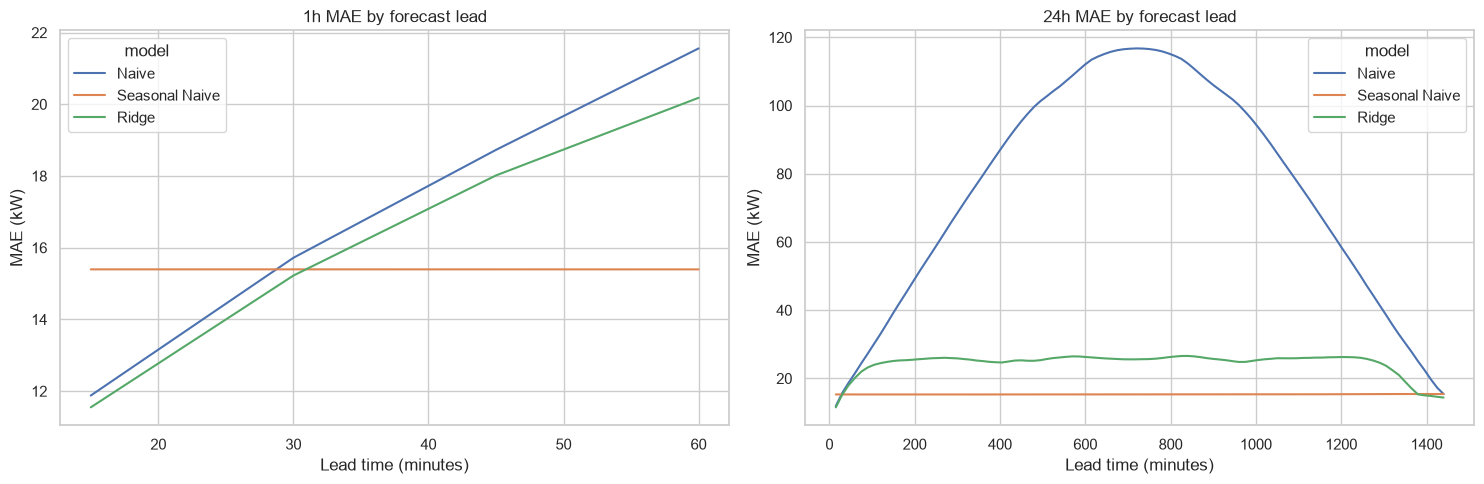

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, horizon_label in zip(axes, HORIZONS):
    subset = step_metrics_df[step_metrics_df["horizon"] == horizon_label]
    sns.lineplot(
        data=subset,
        x="lead_minutes",
        y="MAE",
        hue="model",
        ax=ax,
    )
    ax.set_title(f"{horizon_label} MAE by forecast lead")
    ax.set_xlabel("Lead time (minutes)")
    ax.set_ylabel("MAE (kW)")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "baseline_mae_by_step.png", dpi=160)
plt.show()

## Results

The tables below are also written to `reports/tables/` for use in the project README.

In [6]:
display(metrics_df.sort_values(["horizon_steps", "MAE"]))
display(alpha_selection_df)

,horizon,horizon_steps,model,selected_alpha,MAE,RMSE,MAPE,Endpoint_MAE
1,1h,4,Seasonal Naive,NaN,15.395150,24.912657,9.443368,15.394528
2,1h,4,Ridge,0.1,16.241292,22.759766,10.033431,20.180177
0,1h,4,Naive,NaN,16.970033,27.091910,10.377395,21.557127
4,24h,96,Seasonal Naive,NaN,15.326554,24.723413,9.399252,15.417331
5,24h,96,Ridge,0.1,24.380781,31.952616,14.574504,14.383238
3,24h,96,Naive,NaN,75.092625,96.866962,44.866767,15.417331


,horizon,alpha,validation_MAE,selected
0,1h,0.1,17.450013,True
1,1h,1.0,17.450059,False
2,1h,10.0,17.450529,False
3,1h,100.0,17.456271,False
4,24h,0.1,26.064851,True
5,24h,1.0,26.064988,False
6,24h,10.0,26.066369,False
7,24h,100.0,26.081110,False
